# Implementing a Perceptron learning algorithm in Python3

The implementation is inspired by the "*Machine Learning with PyTorch and Scikit-Learn*" book from S. Raschka.

Let's implement the Adaline linear neuron in Python3 and apply it to the Iris dataset. We will take an object-oriented approach to define the Adaline interface. It will allow us to initialize new *AdalineGD* object, call a learning function via a *fit* method and make predictions via a separate *predict* method.

Since the perceptron rule and Adalie are very similar, we will take the perceptron implementation defined in the previous laboratory class and change the *fit* method so that the weight and bias parameters are now updated by minimizing the loss function via gradient descent.

In [56]:
import numpy as np

Let's recap the perceptron learning algorithm:

> Initilize the weights and bias unit to 0 or small random numbers
>
>> For each training epoch:
>>
>>> For every $(x^{(i)}, y^{(i)}) ∈ 𝒟$:
>>>
>>>> Compute the output value, $\hat{y}^{(i)} = \sigma (x^{(i)T}w+b)$
>>>>
>>>>> For weight $j$ in ${1, ..., m}£:
>>>>>
>>>>> Update the weights, $w_j = w_j - \eta \frac{\delta L}{\delta w_j}$ 
>>>>>
>>>>> Update the bias unit, $b = b - \eta \frac{\delta L}{\delta b}$
>>>>>
>>>> end for
>>>>
>>>
>>> end for
>>
>> end for
>


In [57]:
class AdalineGD:

    def __init__(self, eta: float = 0.01, epochs: int = 50, random_state: int = 1):
        self.eta: float = eta
        self.__epochs: int = epochs
        self.__random_state: int = random_state

    def fit(self, X: np.ndarray, y: np.ndarray):
        self.__weights: np.ndarray = self.__initialize_weights(self.__random_state, X)
        self.__bias: np.float64 = self.__initialize_bias()
        self.losses: list = list()

        for _ in range(self.__epochs):
            net_input = self.__net_input(X)
            output = self.__activation(net_input)
            errors = y - output
            self.__weights += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.__bias += self.eta * 2.0 * errors.mean()
            loss = (errors**2).mean()
            self.losses.append(loss)
    
    def __initialize_weights(self, random_state: int, X: np.ndarray) -> np.ndarray:
        """Initialize the weights.
        
        The method initialize the weights to a vector with real numbers and
        dimension m, which stands for the number of dimensions (features) in
        the dataset.
        Notice that the initial weight vector contains small random numbers
        drawn from a normal distribution with a standard deviation of 0.01
        via the NumpY random number generator.
        """
        rgen = np.random.RandomState(random_state)
        return rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])

    def __initialize_bias(self) -> np.float64:
        """Initialize the bias to an initial value 0
        """
        return np.float64(0.)
    
    def __net_input(self, X: np.ndarray) -> np.float64:
        return np.dot(X, self.__weights) + self.__bias
    
    def __activation(self, X: np.ndarray) -> np.ndarray:
        return X

    def predict(self, X: np.ndarray):
        return np.where(self.__activation(self.__net_input(X)) >= 0.5, 1, 0)

Note that the weight updates via the partial derivatives $\frac{\delta L}{\delta w_j}$ involve the feature values $x_j$, which we can compute by multiplying ```errors``` with each feature value for each weight:

```python
for weight_j in range(self.__weight.shape[0]):
    self.__weight[weight_j] += self.eta * (2.0 * (X[:, weight_j] * error)).mean()
```

To implement the weight update more efficiently without using a for loop, we use a matrix-vector multiplication between our feature matrix and the error vector, as follow:

```python
self.__weights += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
```

Remember that the perceptron is a binary classifier. We will consider the Iris dataset, selecting only two flower classes, setosa and versicolor. Moreover, we will use only two features for simplicity, sepal length and petl length. This will allow us to visualize the decision regions of the trained model in a scatterplot for learning purposes.

Note also that the ```activation``` method has no effect on the code since it is simply an identity function.

Let's load now the dataset. First, we will use the *pandas* library to load the Iris dataset directly from *UCI Machine Learning Repository* into a ```DataFrame``` object and print the last five lines via the ```tail``` method to check that the data was loaded correctly.

In [58]:
import pandas as pd

In [59]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
df = pd.read_csv(url, header=None, encoding='utf-8')
# TODO: add local loading

In [60]:
df.tail()

,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


Next, we extract the first 100 class labels that correspond to the 50 Iris-setosa and 50 Iris-versicolor flowers and convert the class labels into the two integer class labels, that are 1 for versicolor and 0 for setosa. We assign them to a vector $y$, where the values method of a pandas ```DataFrame``` yields the corresponding NumPy representation.

In [61]:
y = df.iloc[0:100, 4].values
y = np.where(y == 'Iris-setosa', 0, 1)

Similarly, we extract the first feature column (sepal length) and the third feature column (petal length) of those 100 training examples and assign them to a feature matrix $X$, which we can visualize via a two-dimensional scatterplot.

In [62]:
import matplotlib.pyplot as plt

In [63]:
X = df.iloc[0:100, [0, 2]]. values

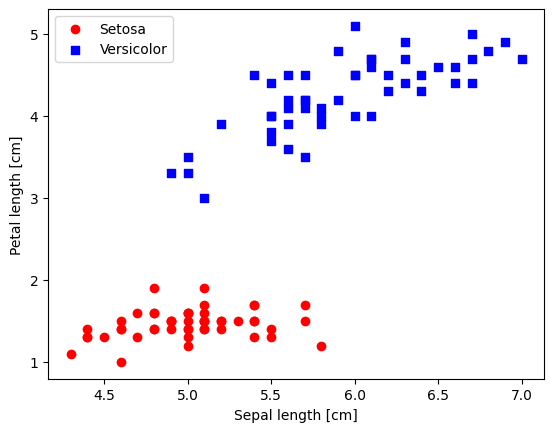

In [64]:
plt.scatter(X[:50, 0], X[:50, 1], color='red', marker='o', label='Setosa')
plt.scatter(X[50:100, 0], X[50:100, 1],color='blue', marker='s', label='Versicolor')
plt.xlabel('Sepal length [cm]')
plt.ylabel('Petal length [cm]')
plt.legend(loc='upper left')
plt.show()

The figure shows the distribution of flower examples in the Iris dataset along the two feature axes: petal length and sepal length (measured in centimeters). In this two-dimensional feature subspace, we can see that a linear decision boundary should be sufficient to separate setosa from versicolor flowers. Thus a linear classifier such as the perceptron should be able to classify the flowers in this dataset perfectly.

Now, it is time to train our adaline algorithm on the Iris data subset that we just extracted. Also, we will plot the misclassification error for each epoch to check whether the algorithm converged and found a decision boundary that separated the two Iris flower classes.

It often requires some experimentation to find a good learning rate $\eta$ for optimal convergence. Let's therefore choose two different learning rates $\eta=0.1$ and $\eta=0.0001$ to start with and plot the loss function versus the nuber of epochs.

In [65]:
adalinegd = AdalineGD(eta=0.1, epochs=15)

In [66]:
adalinegd.fit(X, y)

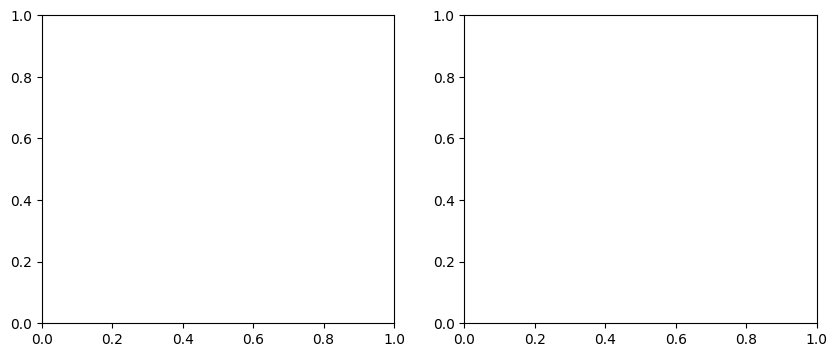

In [67]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

In [68]:
ax[0].plot(range(1, len(adalinegd.losses) + 1), np.log10(adalinegd.losses), marker='o')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('log(Mean Squared Error)')
ax[0].set_title('Adaline - Learning rate 0.1')

Text(0.5, 1.0, 'Adaline - Learning rate 0.1')

In [69]:
adalinegd = AdalineGD(eta=0.0001, epochs=15)

In [70]:
adalinegd.fit(X, y)

In [71]:
ax[1].plot(range(1, len(adalinegd.losses) + 1), adalinegd.losses, marker='o')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Mean Squared Error')
ax[1].set_title('Adaline - Learning rate 0.0001')

Text(0.5, 1.0, 'Adaline - Learning rate 0.0001')

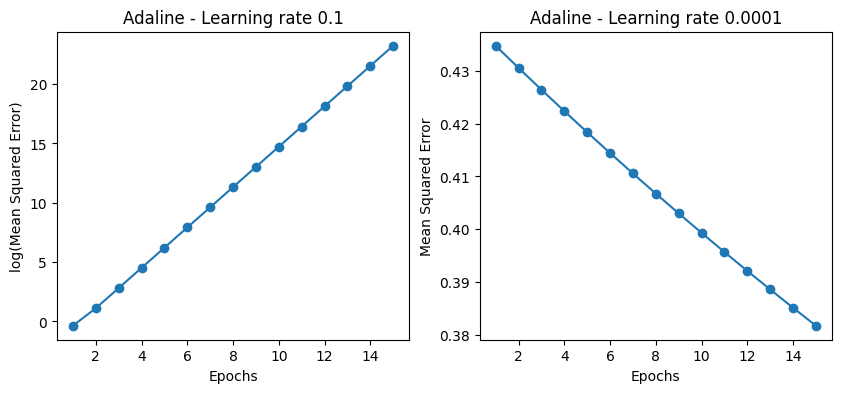

In [72]:
fig

As we can see in the resulting loss function plots above, we encountered two different types of problems. The left chart shows what could happen if we choose a learning rate that is too large. Instead of minimizing the loss funcion, the MSE becomes larger in every epoch, because we overshoot the global minimum. On the other hand, we can see that the loss decreases on the right plot, but the chosen learning rate is so small that the algorithm would require a very large number of epochs to converge to the global loss minimum.

Gradient descent is one of the many algorithms that benefit from feature scaling. For example, the standardization is a normalization procedure that helps gradient descent learning to converge more quickly.

Standardization hifts the mean of each feature so that it is centered at zero and each feature has a standard deviation of 1 (unit variance). For instance, to standardize the $jth$ feature, we can simply subtract the sample mean $\mu_j$ from every training example and divide it by its standard deviation $\sigma_j$: $x^{'}_j = \frac{x_j - \mu_j}{\sigma_j}$. Here $x_j$ is a vector consisting of the $jth$ feature values of all training examples $n$ and this standardization technique is applied to each feature $j$ in out dataset.





One of the reasons why standardization helps with gradient descent learning is that it is easier to find a learning rate that works well for all weights (and the bias). If the features are on vastly different scales, a learning rate that works well for updating one weight might be too large or too small to update the other weight equally well. Overall, using standardized features can stabilize the training such that the optimizer has to go through fewer steps to find a good or optimal solution (the global loss minimum).

Standardization can easily be achieved by using the built-in NumPy methods mean and std:

In [73]:
X_std = np.copy(X)
X_std[:,0] = (X[:,0] - X[:,0].mean()) / X[:,0].std()
X_std[:,1] = (X[:,1] - X[:,1].mean()) / X[:,1].std()

After standardization, we train Adaline again with a learning rate $\eta=0.5$.

In [74]:
adalinegd = AdalineGD(eta=0.5, epochs=20)

In [75]:
adalinegd.fit(X_std, y)

In [76]:
from matplotlib.colors import ListedColormap

In [77]:
def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=f'Class {cl}', 
                    edgecolor='black'
        )

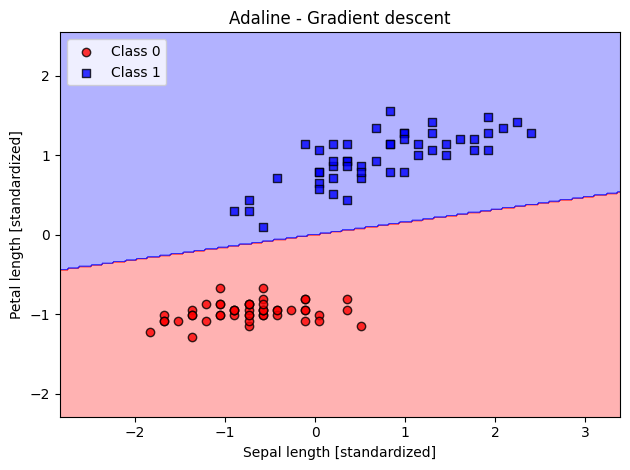

In [78]:
plot_decision_regions(X_std, y, classifier=adalinegd)
plt.title('Adaline - Gradient descent')
plt.xlabel('Sepal length [standardized]')
plt.ylabel('Petal length [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

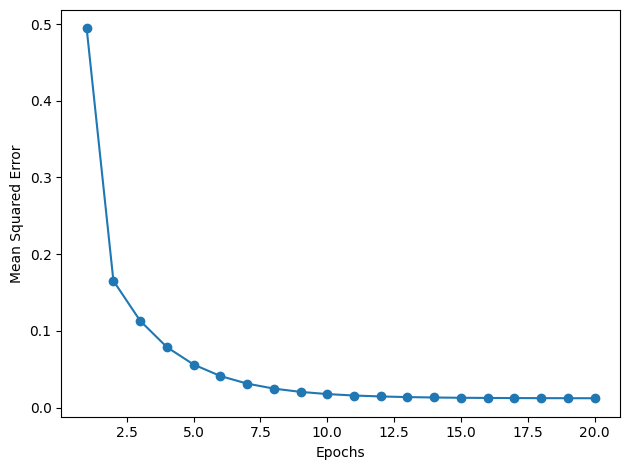

In [80]:
plt.plot(range(1, len(adalinegd.losses) + 1), adalinegd.losses, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.tight_layout()
plt.show()

Adaline has now converged after training on the standardized features.